In [135]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from wordcloud import WordCloud

In [136]:
queimadas = pd.read_csv('focos_br_todos-sats_2024.csv')

# Data Wrangling

In [137]:
# Estrutura do DataFrame
queimadas.info()
#Qual o número de linhas e colunas?
print(queimadas.shape)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8144823 entries, 0 to 8144822
Data columns (total 13 columns):
 #   Column                 Dtype  
---  ------                 -----  
 0   latitude               float64
 1   longitude              float64
 2   data_pas               object 
 3   satelite               object 
 4   pais                   object 
 5   estado                 object 
 6   municipio              object 
 7   bioma                  object 
 8   numero_dias_sem_chuva  float64
 9   precipitacao           float64
 10  risco_fogo             float64
 11  id_area_industrial     int64  
 12  frp                    float64
dtypes: float64(6), int64(1), object(6)
memory usage: 807.8+ MB
(8144823, 13)


O numero de linhas é 8.144.823 para 14 colunas.


**Tabela 1: Dicionário de Dados**

| Coluna | Descrição | Tipo de Dado |
| :--- | :--- | :--- |
| data_pas | Data e hora do registro do foco de calor. | object (string) |
| satelite | Nome do satélite que detectou o foco. | object (string) |
| pais | País onde o foco foi detectado. | object (string) |
| estado | Estado da federação onde o foco foi detectado. | object (string) |
| municipio | Município onde o foco foi detectado. | object (string) |
| bioma | Bioma onde o foco foi detectado. | object (string) |
| diasemchuva | Número de dias consecutivos sem chuva no local. | float64 |
| precipitacao | Precipitação (chuva) acumulada (em mm) no dia. | float64 |
| riscofogo | Risco de fogo calculado pelo INPE. | float64 |
| latitude | Coordenada de latitude do foco (em graus decimais). | float64 |
| longitude | Coordenada de longitude do foco (em graus decimais). | float64 |
| frp | Fire Radiative Power, uma medida da energia liberada pelo fogo. | float64 |

In [138]:
queimadas.head()

,latitude,longitude,data_pas,satelite,pais,estado,municipio,bioma,numero_dias_sem_chuva,precipitacao,risco_fogo,id_area_industrial,frp
0,4.27167,-60.69947,2024-01-02 02:06:00,TERRA_M-M,Brasil,RORAIMA,PACARAIMA,Amazônia,7.0,0.00,1.00,0,14.4
1,-9.55578,-35.70564,2024-01-02 04:08:00,NPP-375D,Brasil,ALAGOAS,MACEIÓ,Mata Atlântica,-999.0,0.00,1.00,0,0.4
2,-9.55515,-35.71013,2024-01-02 04:08:00,NPP-375D,Brasil,ALAGOAS,MACEIÓ,Mata Atlântica,-999.0,0.00,1.00,0,2.7
3,-7.36323,-39.94515,2024-01-02 04:08:00,NPP-375D,Brasil,PERNAMBUCO,BODOCÓ,Caatinga,7.0,1.32,0.54,0,2.1
4,-3.51178,-40.13655,2024-01-02 04:06:00,NPP-375D,Brasil,CEARÁ,SANTANA DO ACARAÚ,Caatinga,3.0,3.38,0.00,0,1.0


In [139]:
# dados ausentes
queimadas.isnull().sum()

,0
latitude,0
longitude,0
data_pas,0
satelite,0
pais,0
estado,0
municipio,0
bioma,1
numero_dias_sem_chuva,11219
precipitacao,11219


In [140]:
# linhas duplicadas
queimadas.duplicated().sum()

np.int64(0)

Sem linhas duplicadas e existem alguns poucos dados ausentes

In [141]:
# Conta o número de valores ausentes por linha
missing_per_row = queimadas.isna().sum(axis=1)

# Filtra: mantém linhas que tenham até 1 valor ausente
# ou que tenham mais de 1, mas sendo todas as ausências só em 'frp'
queimadas_filtrado = queimadas[(missing_per_row <= 1) |
                 ((missing_per_row == 1) & (queimadas['frp'].isna()))]

In [142]:
queimadas_filtrado.isnull().sum()

,0
latitude,0
longitude,0
data_pas,0
satelite,0
pais,0
estado,0
municipio,0
bioma,0
numero_dias_sem_chuva,0
precipitacao,0


Como existem bastantes registros faltantes em FRP, simplesmente removê-los pode retirar informações interessantes. Ainda que o conjunto original seja grande, utilizar alguma abordagem para preencher esses dados pode contribuir para a precisão da visualização final.

In [143]:
queimadas_filtrado = queimadas_filtrado.copy()

# casting do tipo de dados pra datetime
queimadas_filtrado["data_pas"] = pd.to_datetime(queimadas_filtrado["data_pas"], errors="coerce")

In [144]:
# Criando colunas para analises temporais
queimadas_filtrado["ano"] = queimadas_filtrado["data_pas"].dt.year
queimadas_filtrado["mes"] = queimadas_filtrado["data_pas"].dt.month
queimadas_filtrado["dia"] = queimadas_filtrado["data_pas"].dt.day
queimadas_filtrado["dia_semana"] = queimadas_filtrado["data_pas"].dt.day_name()
queimadas_filtrado["semana_ano"] = queimadas_filtrado["data_pas"].dt.isocalendar().week

In [145]:
queimadas_filtrado.describe()

,latitude,longitude,data_pas,numero_dias_sem_chuva,precipitacao,risco_fogo,id_area_industrial,frp,ano,mes,dia,semana_ano
count,8.133603e+06,8.133603e+06,8133603,8.133603e+06,8.133603e+06,8.133603e+06,8133603.0,7.797448e+06,8133603.0,8.133603e+06,8.133603e+06,8133603.0
mean,-1.006430e+01,-5.340961e+01,2024-08-26 13:50:18.465690624,2.952746e+01,4.391472e-01,-1.010050e+01,0.0,3.408784e+01,2024.0,8.339399e+00,1.553935e+01,34.535267
min,-3.371535e+01,-7.372144e+01,2024-01-01 00:06:16,-9.990000e+02,0.000000e+00,-9.990000e+02,0.0,-3.800000e+00,2024.0,1.000000e+00,1.000000e+00,1.0
25%,-1.386071e+01,-5.777930e+01,2024-08-10 13:05:53,6.000000e+00,0.000000e+00,8.200000e-01,0.0,3.400000e+00,2024.0,8.000000e+00,8.000000e+00,32.0
50%,-9.169830e+00,-5.359660e+01,2024-09-03 16:26:00,2.000000e+01,0.000000e+00,1.000000e+00,0.0,9.100000e+00,2024.0,9.000000e+00,1.500000e+01,36.0
75%,-6.509400e+00,-4.822158e+01,2024-09-24 11:35:57,6.300000e+01,0.000000e+00,1.000000e+00,0.0,4.430000e+01,2024.0,9.000000e+00,2.300000e+01,39.0
max,5.163930e+00,-3.479613e+01,2024-12-31 23:50:00,1.200000e+02,2.529800e+02,1.000000e+00,0.0,8.094300e+03,2024.0,1.200000e+01,3.100000e+01,52.0
std,5.951345e+00,6.914396e+00,NaN,9.935811e+01,2.585437e+00,1.040730e+02,0.0,6.461029e+01,0.0,2.064677e+00,8.892084e+00,8.954733


Agora chegou a hora de lidar com os valores de FRP. Para preencher esses valores faltantes, vai ser feito um agrupamento entre mês e estado, já que esses valores variam com a sazonalidade, que depende de cada região.

In [146]:
queimadas_filtrado["frp"] = queimadas_filtrado.groupby(["estado", "mes"])["frp"].transform(
    lambda x: x.fillna(x.median())
)

In [147]:
queimadas_filtrado.isnull().sum()

,0
latitude,0
longitude,0
data_pas,0
satelite,0
pais,0
estado,0
municipio,0
bioma,0
numero_dias_sem_chuva,0
precipitacao,0


In [148]:
queimadas_filtrado.describe()

,latitude,longitude,data_pas,numero_dias_sem_chuva,precipitacao,risco_fogo,id_area_industrial,frp,ano,mes,dia,semana_ano
count,8.133603e+06,8.133603e+06,8133603,8.133603e+06,8.133603e+06,8.133603e+06,8133603.0,8.133603e+06,8133603.0,8.133603e+06,8.133603e+06,8133603.0
mean,-1.006430e+01,-5.340961e+01,2024-08-26 13:50:18.465690624,2.952746e+01,4.391472e-01,-1.010050e+01,0.0,3.309705e+01,2024.0,8.339399e+00,1.553935e+01,34.535267
min,-3.371535e+01,-7.372144e+01,2024-01-01 00:06:16,-9.990000e+02,0.000000e+00,-9.990000e+02,0.0,-3.800000e+00,2024.0,1.000000e+00,1.000000e+00,1.0
25%,-1.386071e+01,-5.777930e+01,2024-08-10 13:05:53,6.000000e+00,0.000000e+00,8.200000e-01,0.0,3.600000e+00,2024.0,8.000000e+00,8.000000e+00,32.0
50%,-9.169830e+00,-5.359660e+01,2024-09-03 16:26:00,2.000000e+01,0.000000e+00,1.000000e+00,0.0,9.200000e+00,2024.0,9.000000e+00,1.500000e+01,36.0
75%,-6.509400e+00,-4.822158e+01,2024-09-24 11:35:57,6.300000e+01,0.000000e+00,1.000000e+00,0.0,3.970000e+01,2024.0,9.000000e+00,2.300000e+01,39.0
max,5.163930e+00,-3.479613e+01,2024-12-31 23:50:00,1.200000e+02,2.529800e+02,1.000000e+00,0.0,8.094300e+03,2024.0,1.200000e+01,3.100000e+01,52.0
std,5.951345e+00,6.914396e+00,NaN,9.935811e+01,2.585437e+00,1.040730e+02,0.0,6.344853e+01,0.0,2.064677e+00,8.892084e+00,8.954733


In [149]:
queimadas_filtrado.info()

<class 'pandas.core.frame.DataFrame'>
Index: 8133603 entries, 0 to 8144822
Data columns (total 18 columns):
 #   Column                 Dtype         
---  ------                 -----         
 0   latitude               float64       
 1   longitude              float64       
 2   data_pas               datetime64[ns]
 3   satelite               object        
 4   pais                   object        
 5   estado                 object        
 6   municipio              object        
 7   bioma                  object        
 8   numero_dias_sem_chuva  float64       
 9   precipitacao           float64       
 10  risco_fogo             float64       
 11  id_area_industrial     int64         
 12  frp                    float64       
 13  ano                    int32         
 14  mes                    int32         
 15  dia                    int32         
 16  dia_semana             object        
 17  semana_ano             UInt32        
dtypes: UInt32(1), datetime64[ns

In [150]:
# Seleciona automaticamente todas as colunas que são do tipo 'object'
colunas_para_converter = queimadas_filtrado.select_dtypes(include=['object']).columns

for coluna in colunas_para_converter:
    queimadas_filtrado[coluna] = queimadas_filtrado[coluna].astype('category')

In [151]:
queimadas_filtrado.info()

<class 'pandas.core.frame.DataFrame'>
Index: 8133603 entries, 0 to 8144822
Data columns (total 18 columns):
 #   Column                 Dtype         
---  ------                 -----         
 0   latitude               float64       
 1   longitude              float64       
 2   data_pas               datetime64[ns]
 3   satelite               category      
 4   pais                   category      
 5   estado                 category      
 6   municipio              category      
 7   bioma                  category      
 8   numero_dias_sem_chuva  float64       
 9   precipitacao           float64       
 10  risco_fogo             float64       
 11  id_area_industrial     int64         
 12  frp                    float64       
 13  ano                    int32         
 14  mes                    int32         
 15  dia                    int32         
 16  dia_semana             category      
 17  semana_ano             UInt32        
dtypes: UInt32(1), category(6), 

In [152]:
queimadas_filtrado.describe()

,latitude,longitude,data_pas,numero_dias_sem_chuva,precipitacao,risco_fogo,id_area_industrial,frp,ano,mes,dia,semana_ano
count,8.133603e+06,8.133603e+06,8133603,8.133603e+06,8.133603e+06,8.133603e+06,8133603.0,8.133603e+06,8133603.0,8.133603e+06,8.133603e+06,8133603.0
mean,-1.006430e+01,-5.340961e+01,2024-08-26 13:50:18.465690624,2.952746e+01,4.391472e-01,-1.010050e+01,0.0,3.309705e+01,2024.0,8.339399e+00,1.553935e+01,34.535267
min,-3.371535e+01,-7.372144e+01,2024-01-01 00:06:16,-9.990000e+02,0.000000e+00,-9.990000e+02,0.0,-3.800000e+00,2024.0,1.000000e+00,1.000000e+00,1.0
25%,-1.386071e+01,-5.777930e+01,2024-08-10 13:05:53,6.000000e+00,0.000000e+00,8.200000e-01,0.0,3.600000e+00,2024.0,8.000000e+00,8.000000e+00,32.0
50%,-9.169830e+00,-5.359660e+01,2024-09-03 16:26:00,2.000000e+01,0.000000e+00,1.000000e+00,0.0,9.200000e+00,2024.0,9.000000e+00,1.500000e+01,36.0
75%,-6.509400e+00,-4.822158e+01,2024-09-24 11:35:57,6.300000e+01,0.000000e+00,1.000000e+00,0.0,3.970000e+01,2024.0,9.000000e+00,2.300000e+01,39.0
max,5.163930e+00,-3.479613e+01,2024-12-31 23:50:00,1.200000e+02,2.529800e+02,1.000000e+00,0.0,8.094300e+03,2024.0,1.200000e+01,3.100000e+01,52.0
std,5.951345e+00,6.914396e+00,NaN,9.935811e+01,2.585437e+00,1.040730e+02,0.0,6.344853e+01,0.0,2.064677e+00,8.892084e+00,8.954733


alguns valores como o min estao negativos, pois existem invalidos no dataset, a seguir valores inválidos ou problemáticos (como frp menor ou igual a 0) sao removidos, pois foram interpretados como incorretos, podendo gerar resultados indesejados.

In [153]:
print("--- ANTES DA REMOÇÃO ---")
print(f"Formato do DataFrame: {queimadas_filtrado.shape}")
# Mostra o mínimo problemático antes de limpar
print("\nValores mínimos problemáticos antes:")
print(queimadas_filtrado[['frp', 'numero_dias_sem_chuva', 'risco_fogo']].min())


# condições de dados válidos que serao mantidos
condicao_frp_valido = queimadas_filtrado['frp'] > 0
condicao_dias_valido = queimadas_filtrado['numero_dias_sem_chuva'] >= 0
condicao_risco_valido = queimadas_filtrado['risco_fogo'] >= 0

# mantem as linhas que atendem a todas as condicoes
registros_antes = len(queimadas_filtrado)
queimadas_filtrado = queimadas_filtrado[condicao_frp_valido & condicao_dias_valido & condicao_risco_valido]
registros_depois = len(queimadas_filtrado)


print("\n--- DEPOIS DA REMOÇÃO ---")
print(f"Formato do DataFrame: {queimadas_filtrado.shape}")
print(f"Total de registros removidos: {registros_antes - registros_depois}")

# Verificação final
print(queimadas_filtrado[['frp', 'numero_dias_sem_chuva', 'risco_fogo']].describe().to_string())

--- ANTES DA REMOÇÃO ---
Formato do DataFrame: (8133603, 18)

Valores mínimos problemáticos antes:
frp                       -3.8
numero_dias_sem_chuva   -999.0
risco_fogo              -999.0
dtype: float64

--- DEPOIS DA REMOÇÃO ---
Formato do DataFrame: (7982064, 18)
Total de registros removidos: 151539
                frp  numero_dias_sem_chuva    risco_fogo
count  7.982064e+06           7.982064e+06  7.982064e+06
mean   3.324835e+01           3.773056e+01  8.528404e-01
std    6.371431e+01           3.929961e+01  2.735117e-01
min    1.000000e-01           0.000000e+00  0.000000e+00
25%    3.600000e+00           6.000000e+00  8.400000e-01
50%    9.200000e+00           2.000000e+01  1.000000e+00
75%    4.020000e+01           6.400000e+01  1.000000e+00
max    8.094300e+03           1.200000e+02  1.000000e+00


In [154]:
queimadas_filtrado.describe()

,latitude,longitude,data_pas,numero_dias_sem_chuva,precipitacao,risco_fogo,id_area_industrial,frp,ano,mes,dia,semana_ano
count,7.982064e+06,7.982064e+06,7982064,7.982064e+06,7.982064e+06,7.982064e+06,7982064.0,7.982064e+06,7982064.0,7.982064e+06,7.982064e+06,7982064.0
mean,-1.005095e+01,-5.348375e+01,2024-08-26 11:58:52.773505536,3.773056e+01,4.337427e-01,8.528404e-01,0.0,3.324835e+01,2024.0,8.337108e+00,1.553256e+01,34.527695
min,-3.339217e+01,-7.372144e+01,2024-01-01 00:06:16,0.000000e+00,0.000000e+00,0.000000e+00,0.0,1.000000e-01,2024.0,1.000000e+00,1.000000e+00,1.0
25%,-1.373340e+01,-5.782030e+01,2024-08-10 16:26:00,6.000000e+00,0.000000e+00,8.400000e-01,0.0,3.600000e+00,2024.0,8.000000e+00,8.000000e+00,32.0
50%,-9.166000e+00,-5.365322e+01,2024-09-03 06:45:57.500000,2.000000e+01,0.000000e+00,1.000000e+00,0.0,9.200000e+00,2024.0,9.000000e+00,1.500000e+01,36.0
75%,-6.549300e+00,-4.830562e+01,2024-09-23 19:45:52.249999872,6.400000e+01,0.000000e+00,1.000000e+00,0.0,4.020000e+01,2024.0,9.000000e+00,2.300000e+01,39.0
max,5.163930e+00,-3.505486e+01,2024-12-31 23:50:00,1.200000e+02,2.192000e+02,1.000000e+00,0.0,8.094300e+03,2024.0,1.200000e+01,3.100000e+01,52.0
std,5.893965e+00,6.880264e+00,NaN,3.929961e+01,2.560742e+00,2.735117e-01,0.0,6.371431e+01,0.0,2.046710e+00,8.896807e+00,8.869158


In [155]:
queimadas_filtrado.head()

,latitude,longitude,data_pas,satelite,pais,estado,municipio,bioma,numero_dias_sem_chuva,precipitacao,risco_fogo,id_area_industrial,frp,ano,mes,dia,dia_semana,semana_ano
0,4.27167,-60.69947,2024-01-02 02:06:00,TERRA_M-M,Brasil,RORAIMA,PACARAIMA,Amazônia,7.0,0.00,1.00,0,14.4,2024,1,2,Tuesday,1
3,-7.36323,-39.94515,2024-01-02 04:08:00,NPP-375D,Brasil,PERNAMBUCO,BODOCÓ,Caatinga,7.0,1.32,0.54,0,2.1,2024,1,2,Tuesday,1
4,-3.51178,-40.13655,2024-01-02 04:06:00,NPP-375D,Brasil,CEARÁ,SANTANA DO ACARAÚ,Caatinga,3.0,3.38,0.00,0,1.0,2024,1,2,Tuesday,1
5,-21.89247,-46.96316,2024-01-02 04:12:00,NPP-375D,Brasil,SÃO PAULO,VARGEM GRANDE DO SUL,Cerrado,0.0,0.67,0.19,0,0.9,2024,1,2,Tuesday,1
6,-21.88905,-46.96251,2024-01-02 04:12:00,NPP-375D,Brasil,SÃO PAULO,VARGEM GRANDE DO SUL,Cerrado,0.0,0.64,0.19,0,0.6,2024,1,2,Tuesday,1


# Análise Descritiva Inicial
### Risco de Fogo

A maior parte dos registros está concentrada em níveis baixos de risco, mas os valores máximos mostram que existem momentos e locais com risco crítico de incêndio.

### Dias sem Chuva

Boa parte dos focos ocorre após períodos relativamente curtos sem chuva, mas existem casos extremos de estiagem prolongada.

### Precipitação

O padrão predominante é de ausência de chuva no momento dos focos, reforçando a relação direta entre estiagem e incêndios. Contudo, outliers mostram que queimadas também podem ocorrer mesmo após precipitação.

# Análise Exploratória e Visualização de Dados (EDA)



# Análise Temporal

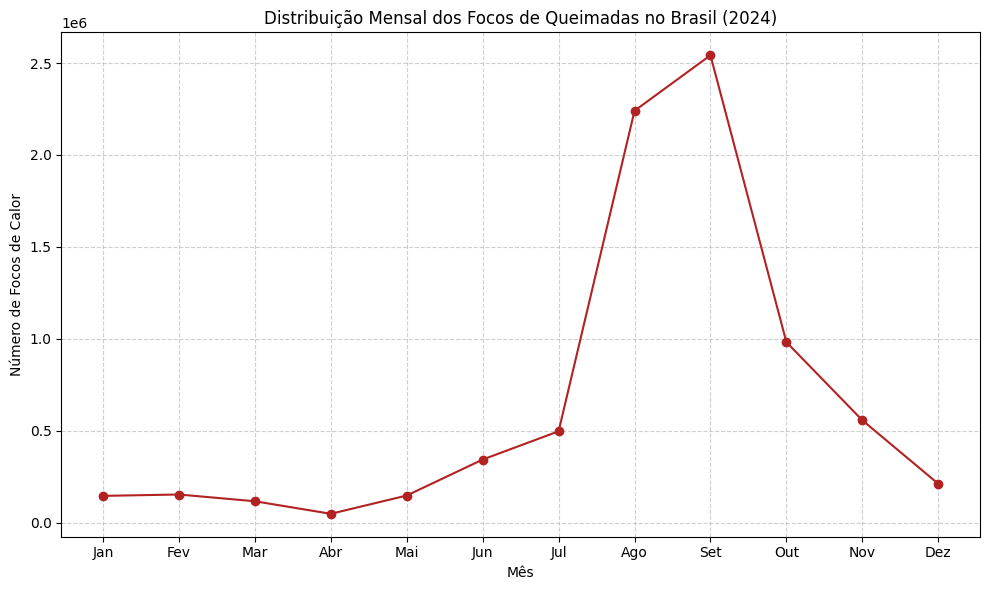

In [156]:
# Contagem de focos por mês
focos_mes = queimadas_filtrado['mes'].value_counts().sort_index()

plt.figure(figsize=(10,6))
plt.plot(focos_mes.index, focos_mes.values, marker='o', linestyle='-', color="firebrick")
plt.title("Distribuição Mensal dos Focos de Queimadas no Brasil (2024)")
plt.xlabel("Mês")
plt.ylabel("Número de Focos de Calor")
plt.xticks(range(1,13),
           ["Jan","Fev","Mar","Abr","Mai","Jun","Jul","Ago","Set","Out","Nov","Dez"])
plt.grid(True, linestyle="--", alpha=0.6)
plt.tight_layout()
plt.show()

Em 2024, o número de queimadas seguiu, a princípio, uma tendência de queda suave e constante. A partir de maio, no entanto, essa tendência se reverteu drasticamente, iniciando com um salto exponencial em junho e atingindo um pico alarmante em setembro. Posteriormente, uma queda acentuada em outubro fez com que os índices retornassem ao padrão de declínio inicial. Esse período também corresponde ao período mais quente e seco nessas regiões, cenário ideal para o aparecimento de focos.

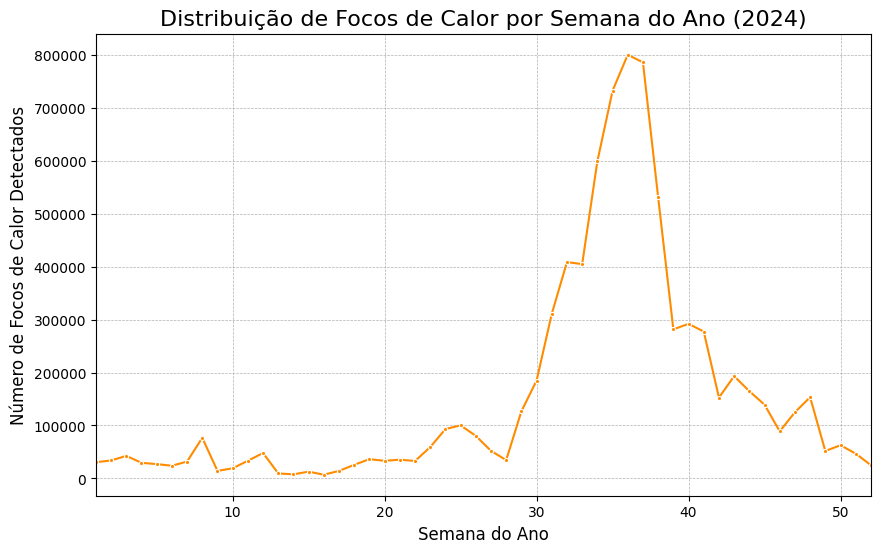

In [157]:
# Agrupa os dados por semana do ano e conta os focos
focos_por_semana = queimadas_filtrado.groupby('semana_ano').size()

plt.figure(figsize=(10, 6))
sns.lineplot(x=focos_por_semana.index, y=focos_por_semana.values, marker='.', color='darkorange')

plt.title('Distribuição de Focos de Calor por Semana do Ano (2024)', fontsize=16)
plt.xlabel('Semana do Ano', fontsize=12)
plt.ylabel('Número de Focos de Calor Detectados', fontsize=12)
plt.xlim(1, 52)
plt.grid(True, which='both', linestyle='--', linewidth=0.5)
plt.show()

Ao observar o gráfico semanal, percebe-se uma pequena anomalia nas semanas iniciais, que logo retornou à normalidade antes do periodo mais intenso.

# Análise Categórica

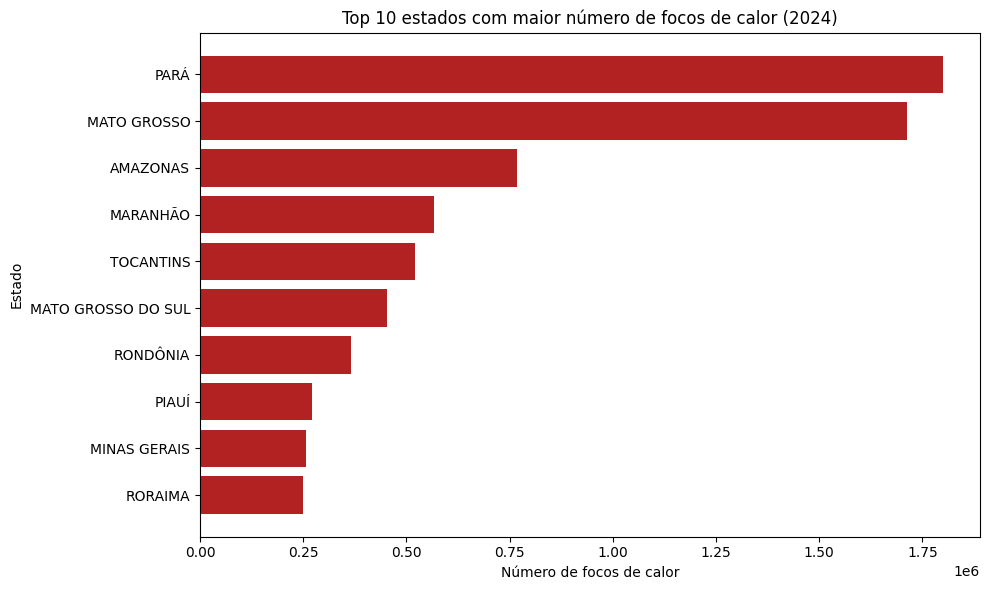

In [158]:
top_estados = queimadas_filtrado['estado'].value_counts().head(10)

plt.figure(figsize=(10,6))
plt.barh(top_estados.index, top_estados.values, color="firebrick")
plt.title("Top 10 estados com maior número de focos de calor (2024)")
plt.xlabel("Número de focos de calor")
plt.ylabel("Estado")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

É interessante notar a proximidade entre os dois estados com mais focos de calor. No grafico que mostra o mapa, eles parecem formar "ilhas de fogo", concentrando um volume significativo de ocorrências em áreas geográficas relativamente proximas.

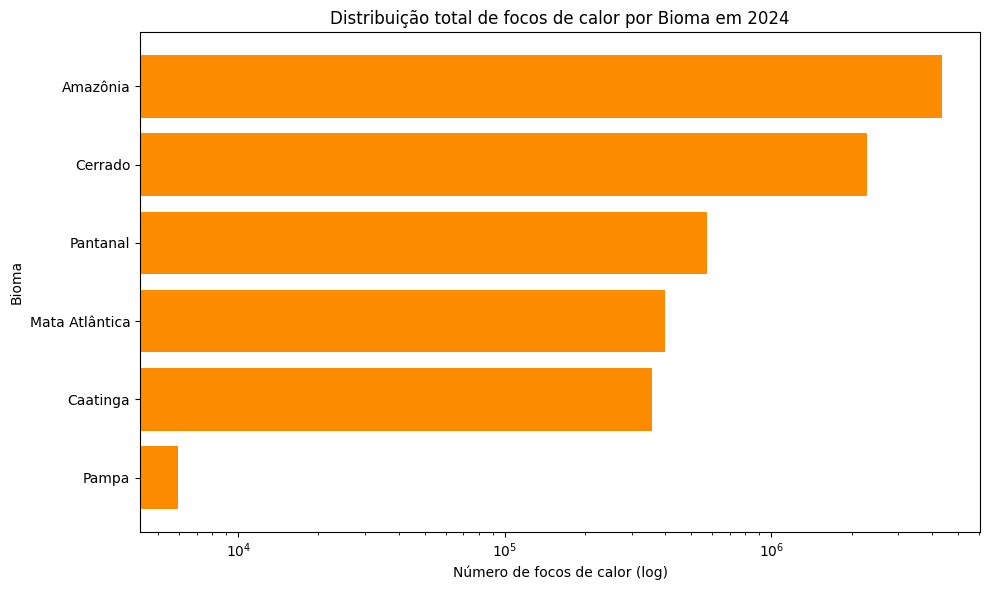

In [159]:
focos_bioma = queimadas_filtrado['bioma'].value_counts().sort_values(ascending=True)

plt.figure(figsize=(10,6))
plt.barh(focos_bioma.index, focos_bioma.values, color="darkorange")
plt.xscale("log")
plt.title("Distribuição total de focos de calor por Bioma em 2024")
plt.xlabel("Número de focos de calor (log)")
plt.ylabel("Bioma")
plt.tight_layout()
plt.show()

In [160]:
focos_bioma = queimadas_filtrado['bioma'].value_counts()
tabela_bioma = pd.DataFrame({
    "Bioma": focos_bioma.index,
    "Focos": focos_bioma.values,
    "Percentual (%)": (focos_bioma.values / focos_bioma.sum() * 100).round(2)
})
print(tabela_bioma)

            Bioma    Focos  Percentual (%)
0        Amazônia  4364169           54.67
1         Cerrado  2282006           28.59
2        Pantanal   576082            7.22
3  Mata Atlântica   397725            4.98
4        Caatinga   356128            4.46
5           Pampa     5954            0.07


A análise do gráfico evidencia uma clara concentração de focos de calor em estados da região amazônica. Este padrão é confirmado pelos dados da tabela, que indicam que 54% de todas as ocorrências foram registradas na Amazônia, seguida pelo Cerrado, que também apresenta uma parcela expressiva dos casos. A predominância dessas regiões fica ainda mais clara ao notar que a maioria dos estados listados na tabela pertence à Amazônia ou ao Nordeste.

In [161]:
tabela_top_estados = top_estados.reset_index()
tabela_top_estados.columns = ["Estado", "Número de Focos"]

print("\nTabela - Top 10 Estados com mais Focos de Calor (2024):\n")
print(tabela_top_estados.to_string(index=False))


Tabela - Top 10 Estados com mais Focos de Calor (2024):

            Estado  Número de Focos
              PARÁ          1799720
       MATO GROSSO          1713338
          AMAZONAS           767555
          MARANHÃO           567818
         TOCANTINS           520793
MATO GROSSO DO SUL           452929
          RONDÔNIA           365249
             PIAUÍ           272055
      MINAS GERAIS           257215
           RORAIMA           250352


O Pará é o estado com o maior número de focos. Regionalmente, Norte, Centro-Oeste e Nordeste são as áreas que apresentam, de forma disparada, a situação mais grave.

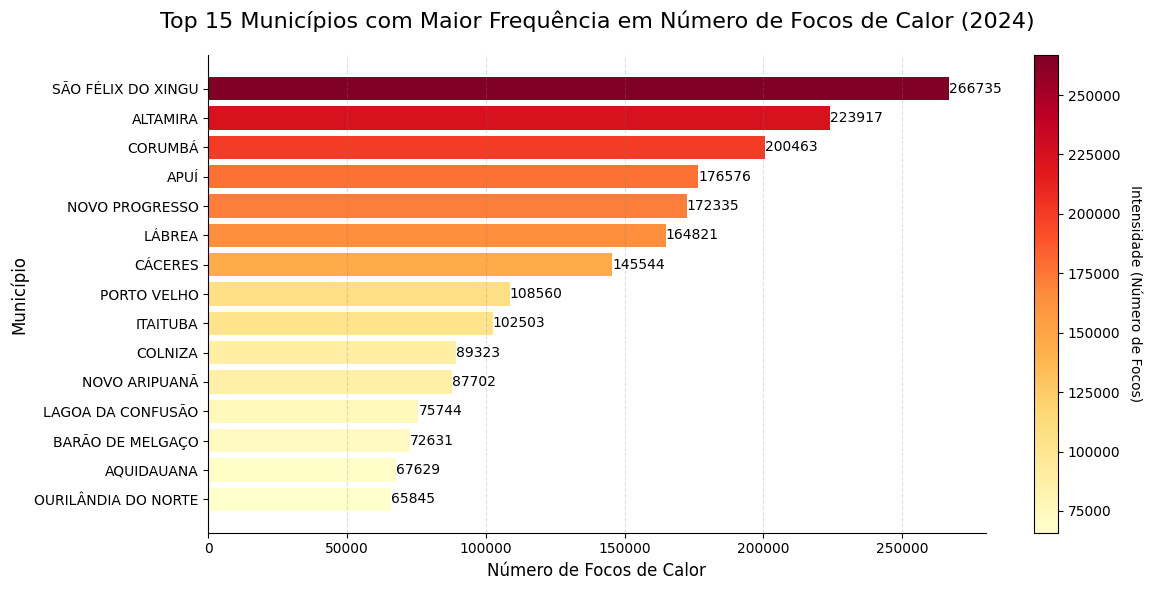

In [162]:
# Calcula os 15 municípios com mais registros e os ordena de forma crescente para o gráfico de barras horizontais.
top_municipios = queimadas_filtrado['municipio'].value_counts().head(15).sort_values(ascending=True)
colormap = plt.get_cmap('YlOrRd')
norm = plt.Normalize(vmin=top_municipios.values.min(), vmax=top_municipios.values.max())

fig, ax = plt.subplots(figsize=(12, 6))
bars = ax.barh(top_municipios.index, top_municipios.values, color=colormap(norm(top_municipios.values)))

ax.set_title("Top 15 Municípios com Maior Frequência em Número de Focos de Calor (2024)", fontsize=16, pad=20)
ax.set_xlabel("Número de Focos de Calor", fontsize=12)
ax.set_ylabel("Município", fontsize=12)

for i, v in enumerate(top_municipios.values):
    ax.text(v + 50, i, str(v), va='center', ha='left')

sm = plt.cm.ScalarMappable(cmap=colormap, norm=norm)
cbar = fig.colorbar(sm, ax=ax)
cbar.set_label('Intensidade (Número de Focos)', rotation=270, labelpad=15)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.xaxis.grid(True, linestyle='--', which='major', color='grey', alpha=.25)

plt.tight_layout()
plt.show()

 Boa parte dos municípios são da Região Norte e do estado do Amazonas, especificamente do bioma amazônico. Em geral, são municípios pequenos de interior e de difícil acesso. Apuí, por exemplo, é um município pequeno que é um grande produtor no ramo de gado e é um dos municípios mais afetados. Ou seja, provavelmente existe alguma correlação com a atividade econômica do local e a falta de fiscalização, resultando no maior aparecimento do fenômeno.

# Análise Geográfica

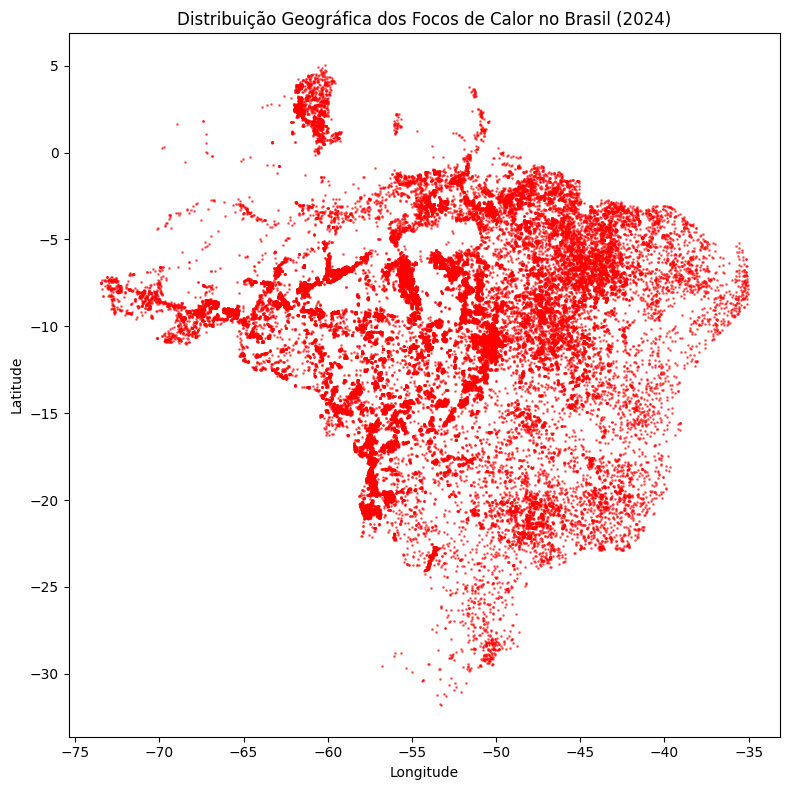

In [163]:
amostra = queimadas_filtrado.sample(n=50000, random_state=42)

plt.figure(figsize=(8,8))
plt.scatter(amostra['longitude'], amostra['latitude'],
            s=1, alpha=0.5, color="red")

plt.title("Distribuição Geográfica dos Focos de Calor no Brasil (2024)")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.tight_layout()
plt.show()

É interessante observar que, nas regiões centrais, parece haver focos de queimadas recorrentes, já em regiões de Cerrado, apesar de também ocorrerem, eles são mais dispersos. Uma possível interpretação seria que essas queimadas mais dispersas são causadas por fenômenos naturais, e as recorrentes são intencionalmente causadas, o que é bem razoável considerando que para limpar um terreno, por vezes, é necessário iniciar focos de incêndio várias vezes, às vezes no mesmo local, até chegar a um estado adequado.

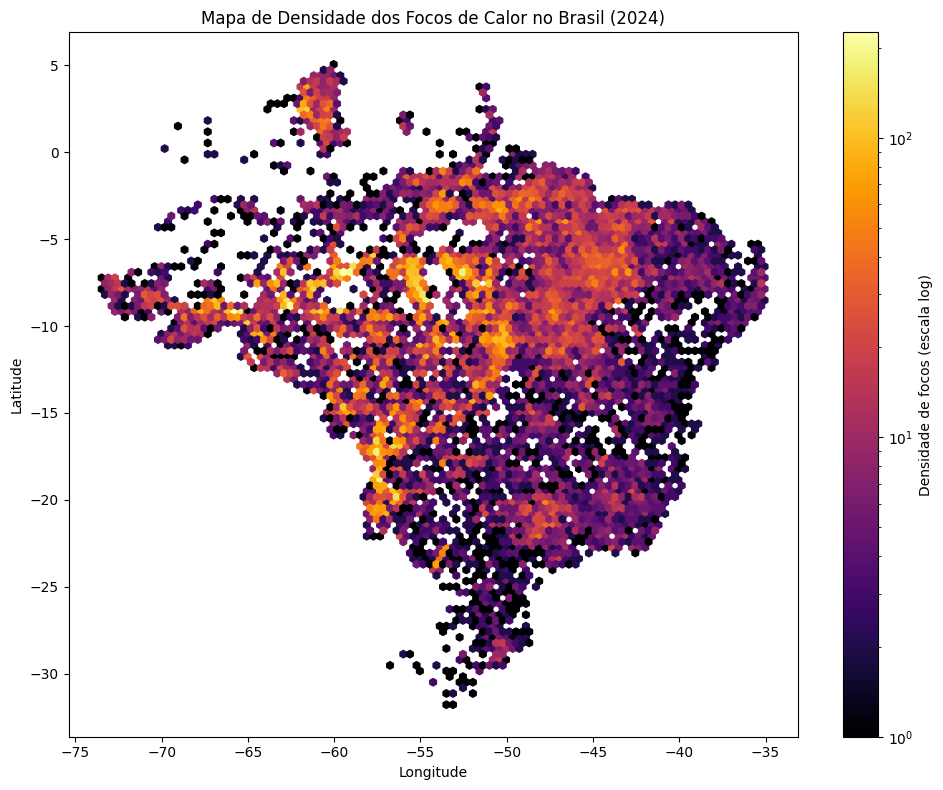

In [164]:
amostra = queimadas_filtrado.sample(n=50000, random_state=42)

plt.figure(figsize=(10,8))
plt.hexbin(amostra['longitude'], amostra['latitude'],
           gridsize=100, cmap="inferno", bins='log')

plt.colorbar(label="Densidade de focos (escala log)")
plt.title("Mapa de Densidade dos Focos de Calor no Brasil (2024)")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.tight_layout()
plt.show()

In [166]:
from google.colab import files

queimadas_filtrado.to_csv('queimadas.csv', index=False)
files.download('queimadas.csv')

KeyboardInterrupt: 

In [ ]:
import pandas as pd
from google.colab import files

#gera uma amostra menor para facilitar o deploy do app, se quiser rodar com o grande tem que mudar o path ja que eu nao fiz uma api pra esse ex.

amostra_queimadas = queimadas_filtrado.sample(n=100000)

amostra_queimadas.to_csv('queimadas_amostra.csv', index=False)
files.download('queimadas_amostra.csv')

Link do deploy usando Streamlit: [Dashboard](https://inpefocosdecalor.streamlit.app/)

Nota: Para o deploy ser rapido eu usei uma amostra bem menor, se precisar rodar com a base processada basta baixar a que eu deixei numa das celulas anteriores e substituir no path do dataframe no app localmente.

Esse grafico é bem revelador em relacao a localizacao precisa, mostrando onde acontecem muitas queimada de forma mais elucidativa, sendo possivel observar que a regiao menos costeira do pais, geralmente interiorana tende a ter mais focos, onde em geral sao regioes exploradas pelo agronegocio.

# Resumo dos Insights

O ano começou com uma leve tendência de queda, que foi drasticamente revertida após maio. Ocorreu um crescimento exponencial a partir de junho, que culminou em um pico alarmante em setembro, seguido por uma queda acentuada em outubro, marcando o retorno à tendência de baixa.

Os biomas mais afetados foram, respectivamente, Amazônia, Cerrado e Pantanal. A alta incidência de focos nessas áreas pode ser atribuída a uma combinação de fatores:

1. Econômicos: A expansão da fronteira agrícola para plantio e pasto.

2. Culturais: O uso tradicional do fogo por pequenos produtores para limpeza de terrenos e renovação de pastagens.

3. Climáticos: A ocorrência de incêndios naturais durante os períodos de seca, aos quais essas regiões são particularmente suscetíveis.

A concentração geográfica dos focos de calor é mais acentuada nas regiões Norte, Centro-Oeste e Nordeste. Esse padrão pode estar associado ao avanço da agropecuária e a desafios de fiscalização em áreas remotas. É importante ressaltar uma dinâmica distinta na região Nordeste, em estados como Maranhão, Piauí e Bahia, embora também apresentem um número elevado de focos, eles se encontram mais dispersos pelo território, em contraste com as áreas de concentração intensa observadas na Amazônia e no Centro-Oeste.

Entre os municípios com maior frequência de registros, destacam-se São Félix do Xingu, Altamira, Corumbá, Apuí, Novo Progresso e Lábrea. Um padrão comum é que são, em geral, municípios do interior, de difícil acesso e localizados em áreas de expansão da fronteira agrícola. Apuí por exemplo é um polo da pecuária, sua presença no topo da lista sugere uma forte correlação entre a atividade econômica local e a alta incidência de queimadas.

# Limitações do Estudo:

É importante reconhecer algumas limitações que contextualizam os resultados desta análise. Primeiramente, ela se limita a 2024, o que oferece uma excelente visão sazonal, mas impede a identificação de tendências de longo prazo que exigiriam uma série histórica maior. Além disso, a natureza dos dados se refere a "focos de calor", que indicam a presença de fogo, mas não medem a "área queimada" real nem a intensidade do incêndio. Por fim, a análise se baseia em uma única fonte de dados, sem o cruzamento com outras informações que poderiam enriquecer o contexto, como dados de desmatamento, fiscalização ambiental ou atividades econômicas locais.

# Sugestões para Trabalhos Futuros:

Uma primeira sugestão seria o desenvolvimento de um modelo preditivo de risco, utilizando redes neurais para, a partir de variáveis climáticas e dados históricos, prever a probabilidade de ocorrência de focos de incêndio em municípios específicos, funcionando como um sistema de alerta. Outra linha de investigação valiosa seria a realização de uma análise de correlação espacial com o uso do solo. Ao cruzar os focos de calor com mapas de desmatamento e atividades agropecuárias, seria possível identificar com maior precisão os principais vetores humanos por trás das queimadas em cada bioma.